<a href="https://colab.research.google.com/github/MNTech955/100-days-of-machine-learning/blob/main/Outlier__Detection__and__Removal__using__the__IQR__Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sample_data/placement.csv')
df.shape


(1000, 3)

In [18]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


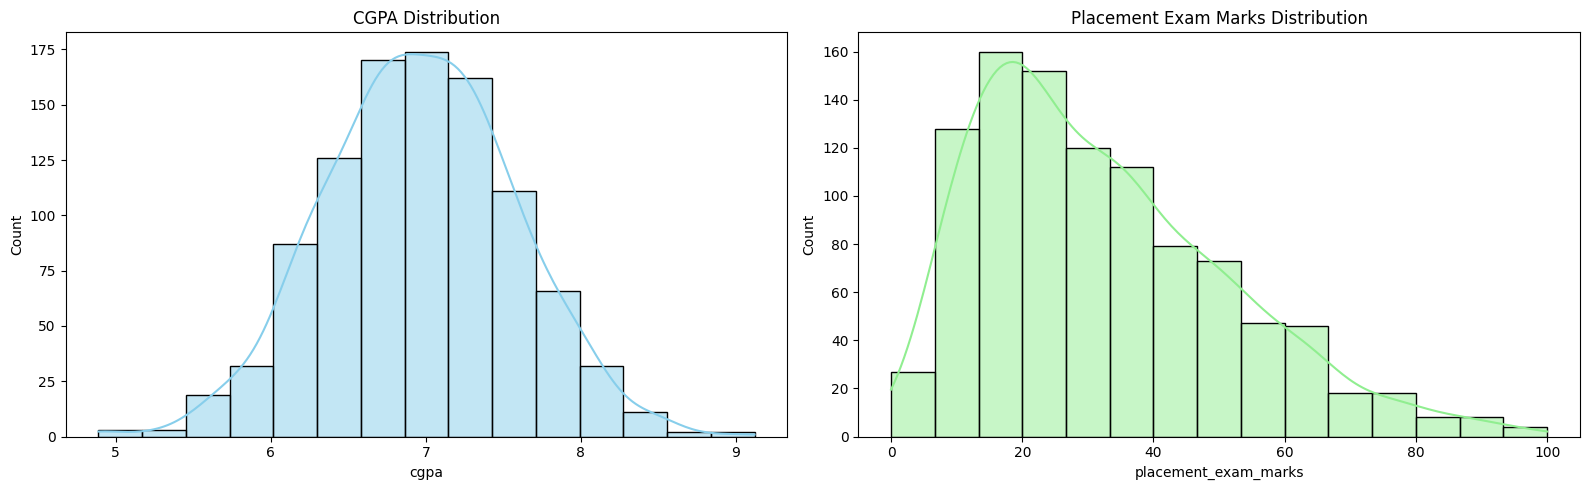

In [20]:
# Columns strip karna
df.columns = df.columns.str.strip()

plt.figure(figsize=(16,5))

# CGPA ka histogram
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True, bins=15, color='skyblue')
plt.title('CGPA Distribution')

# Placement marks ka histogram
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True, bins=15, color='lightgreen')
plt.title('Placement Exam Marks Distribution')

plt.tight_layout()
plt.show()

In [21]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


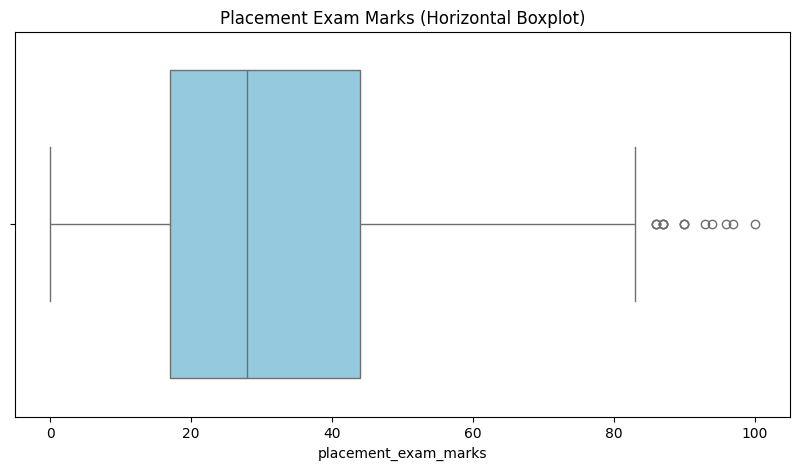

In [23]:
plt.figure(figsize=(10,5))

# Horizontal boxplot
sns.boxplot(x='placement_exam_marks', data=df, orient='h', color='skyblue')
plt.title('Placement Exam Marks (Horizontal Boxplot)')
plt.show()

In [24]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [25]:
percentile75

np.float64(44.0)

In [26]:
iqr = percentile75 - percentile25

In [27]:
iqr

np.float64(27.0)

In [28]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [29]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


Finding Outliers

In [30]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [31]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


Trimming

In [33]:
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.shape


(985, 3)

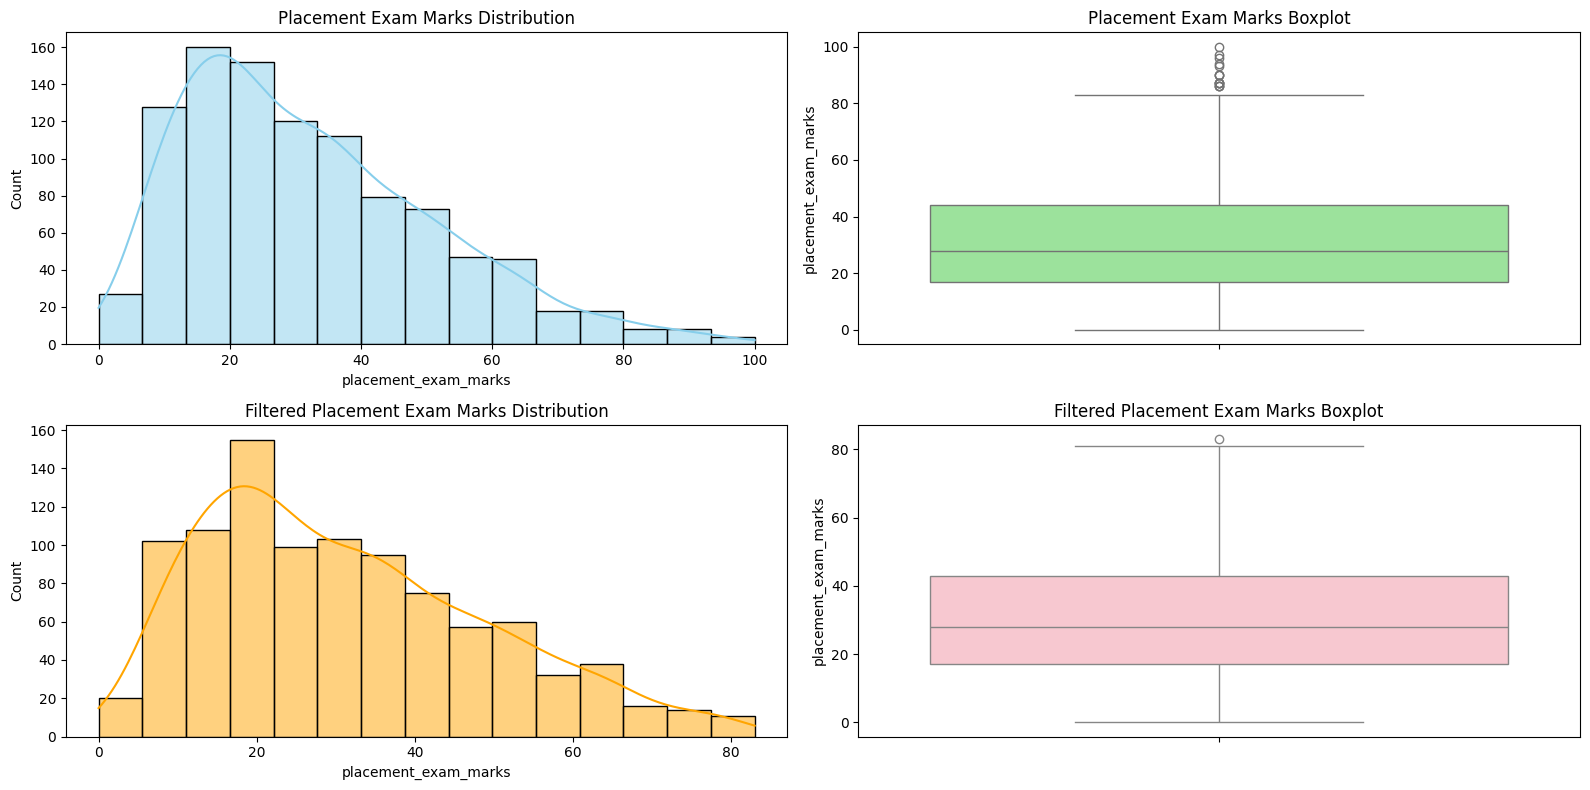

In [35]:
plt.figure(figsize=(16,8))

# 1st subplot - histogram of placement exam marks
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True, bins=15, color='skyblue')
plt.title('Placement Exam Marks Distribution')

# 2nd subplot - boxplot
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'], color='lightgreen')
plt.title('Placement Exam Marks Boxplot')

# 3rd subplot - histogram of filtered data
plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'], kde=True, bins=15, color='orange')
plt.title('Filtered Placement Exam Marks Distribution')

# 4th subplot - boxplot of filtered data
plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'], color='pink')
plt.title('Filtered Placement Exam Marks Boxplot')

plt.tight_layout()
plt.show()

Capping

In [39]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [39]:
# np.where(condtion,true,false)

In [40]:
new_df_cap.shape

(1000, 3)

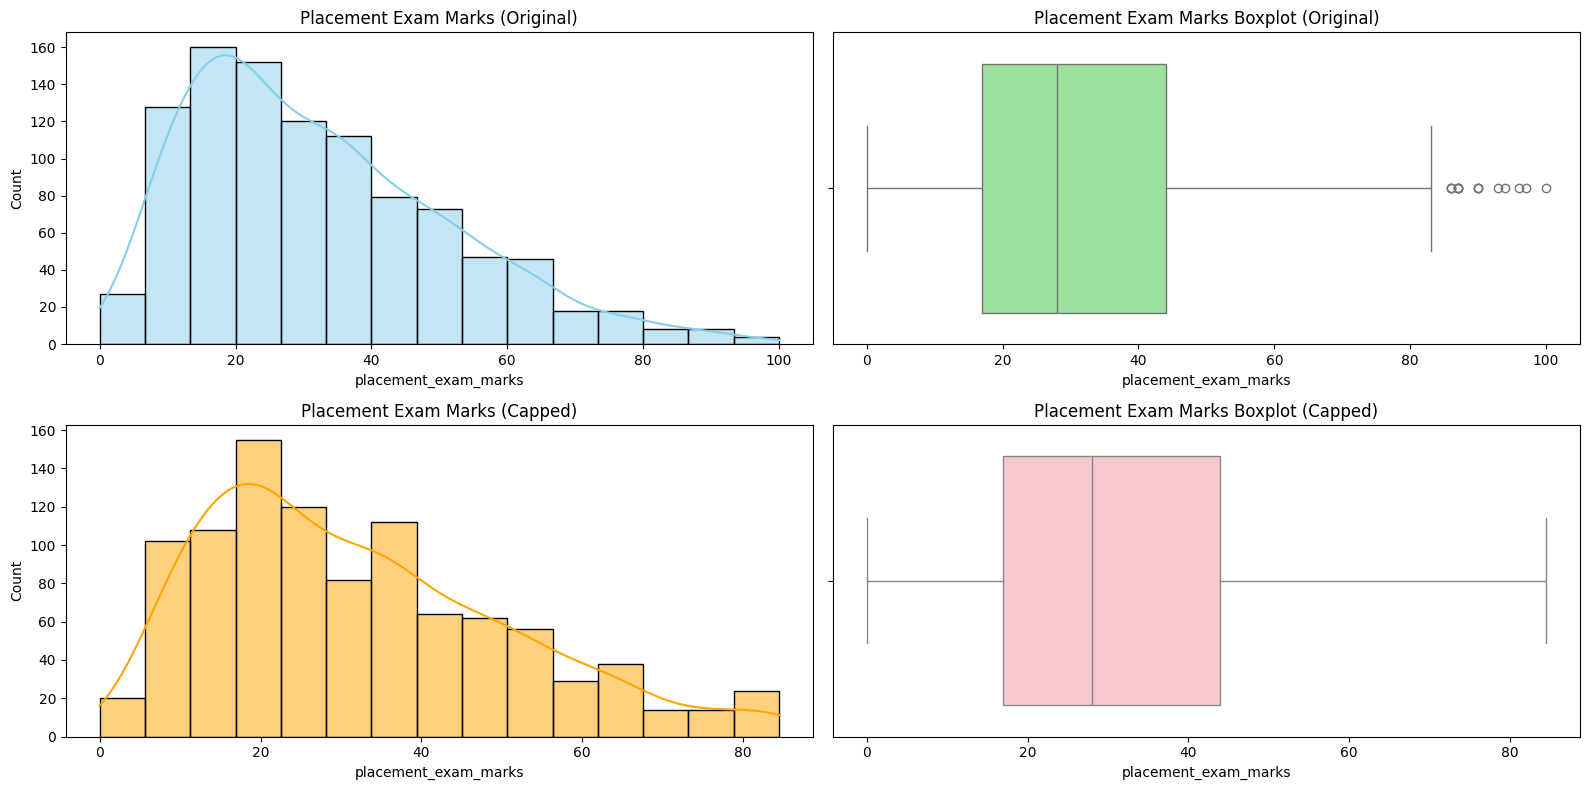

In [41]:
plt.figure(figsize=(16,8))

# Original placement exam marks histogram
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], bins=15, kde=True, color='skyblue')
plt.title('Placement Exam Marks (Original)')

# Original placement exam marks boxplot
plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'], color='lightgreen')
plt.title('Placement Exam Marks Boxplot (Original)')

# Filtered/capped placement exam marks histogram
plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'], bins=15, kde=True, color='orange')
plt.title('Placement Exam Marks (Capped)')

# Filtered/capped placement exam marks boxplot
plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'], color='pink')
plt.title('Placement Exam Marks Boxplot (Capped)')

plt.tight_layout()
plt.show()